# Evaluasi Sistem RAG — Buku Panduan Tugas Akhir

Notebook ini mengevaluasi kualitas sistem RAG menggunakan **RAGAS** (Retrieval Augmented Generation Assessment).

## Metrik Evaluasi

| Metrik | Apa yang Diukur | Rentang |
|--------|----------------|--------|
| **Faithfulness** | Apakah jawaban sesuai dengan konteks yang di-retrieve? | 0–1 |
| **Answer Relevancy** | Apakah jawaban relevan dengan pertanyaan? | 0–1 |
| **Context Precision** | Apakah konteks yang di-retrieve tepat? | 0–1 |
| **Context Recall** | Apakah konteks yang di-retrieve mencakup informasi yang dibutuhkan? | 0–1 |

## 1. Instalasi Dependensi

In [10]:
# Install dependensi evaluasi
# llama-cpp-python untuk load Gemma 4 12B GGUF secara lokal
# ragas untuk framework evaluasi RAG

!pip install langchain-community


In [12]:
!pip install langchain-google-vertexai langchain-openai

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.


  Using cached bottleneck-1.6.0-cp310-cp310-win_amd64.whl.metadata (8.4 kB)
  Using cached google_cloud_aiplatform-1.160.0-py2.py3-none-any.whl.metadata (50 kB)
  Using cached google_cloud_storage-3.13.0-py3-none-any.whl.metadata (15 kB)
  Using cached google_cloud_vectorsearch-0.11.1-py3-none-any.whl.metadata (9.9 kB)
  Using cached numexpr-2.14.1-cp310-cp310-win_amd64.whl.metadata (9.3 kB)
  Using cached pyarrow-23.0.1-cp310-cp310-win_amd64.whl.metadata (3.1 kB)
  Using cached google_cloud_bigquery-3.42.2-py3-none-any.whl.metadata (8.0 kB)
  Using cached google_cloud_resource_manager-1.18.0-py3-none-any.whl.metadata (9.7 kB)
  Using cached google_genai-2.11.0-py3-none-any.whl.metadata (55 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached cryptography-49.0.0-cp39-abi3-win_amd64.whl.metadata (4.3 kB)
  Using cached google_cloud_core-2.6.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached google_resumable_media-2.10.0-py3-none-any.whl.metadata (2.

## 2. Konfigurasi LLM untuk Evaluasi

RAGAS membutuhkan LLM sebagai "judge" untuk menilai kualitas jawaban.

Konfigurasi menggunakan **Gemma 4 12B GGUF** yang di-load secara lokal via `llama-cpp-python`.

> **Catatan:** Sesuaikan `model_path` dengan lokasi file GGUF di mesin Anda.
> Model ini membutuhkan RAM yang cukup (minimal ~8–10 GB untuk Q4 quantization).


In [3]:
from langchain_community.llms import LlamaCpp
from langchain_huggingface import HuggingFaceEmbeddings

# ============================================================
# Gemma 4 12B GGUF via llama-cpp-python
# ============================================================
# Sesuaikan path ke lokasi file GGUF Anda
MODEL_PATH = "Models/gemma-4-12b-it-Q4_K_M.gguf"  # <-- GANTI DENGAN PATH GGUF ANDA

llm = LlamaCpp(
    model_path=MODEL_PATH,
    n_ctx=4096,             # context window
    n_gpu_layers=25,        # -1 = load semua layer ke GPU (sesuaikan jika VRAM terbatas)
    temperature=0.1,        # deterministik untuk evaluasi
    max_tokens=1024,
    verbose=False,
)

# Embedding untuk evaluasi RAGAS (menggunakan BGE-M3 yang sama dengan ingest)
embeddings_eval = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},
)

# Quick test
print("Testing LLM...")
test = llm.invoke("Jawab singkat: 1 + 1 = ?")
print(f"LLM response: {test}")
print("LLM ready!")


llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 2048
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 2048
D:\RAG-PANDUAN-TA\code\.venv311\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 9479.12it/s]


Testing LLM...
LLM response: 
<|channel>thought
<channel|>2
LLM ready!


## 3. Load Vector Database

In [4]:
import sys
sys.path.insert(0, "code")

from embedder import get_embedding_model
from vectorstore import load_vectorstore

# Load embedding model dan ChromaDB
embedding_model = get_embedding_model()
vectorstore = load_vectorstore(embedding_model, "code/chroma_db")

# Verifikasi
count = vectorstore._collection.count()
print(f"Total dokumen di ChromaDB: {count}")

[INFO] Loading embedding model: BAAI/bge-m3


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 13652.56it/s]


[INFO] Embedding model loaded successfully
[INFO] Loading ChromaDB from: D:\RAG-PANDUAN-TA\code\chroma_db
[INFO] Loaded 247 documents from ChromaDB
Total dokumen di ChromaDB: 247


## 4. Buat Retriever

In [5]:
# Buat retriever dari vectorstore
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5},  # Ambil 5 dokumen terdekat
)

# Test retrieval cepat
test_results = retriever.invoke("syarat mengambil tugas akhir")
print(f"Jumlah hasil: {len(test_results)}")
for i, doc in enumerate(test_results):
    print(f"\n--- Hasil {i+1} ---")
    print(f"Chunk ID : {doc.metadata.get('chunk_id')}")
    print(f"Chapter  : {doc.metadata.get('chapter')}")
    print(f"Section  : {doc.metadata.get('section_title')}")
    print(f"Type     : {doc.metadata.get('content_type')}")
    print(f"Content  : {doc.page_content[:120]}...")

Jumlah hasil: 5

--- Hasil 1 ---
Chunk ID : lampiran_7_002
Chapter  : LAMPIRAN
Section  : Persyaratan Pendaftaran Ujian Sarjana / Sidang Tugas Akhir
Type     : persyaratan
Content  : Persyaratan Pendaftaran Ujian Sarjana / Sidang Tugas Akhir...

--- Hasil 2 ---
Chunk ID : bab1_1_6_4_001
Chapter  : BAB I
Section  : Ketentuan Sidang Tugas Akhir
Type     : persyaratan
Content  : 1.6.4 Ketentuan Sidang Tugas Akhir

Sidang tugas akhir dapat dilaksanakan dengan syarat mahasiswa mendaftarkan diri deng...

--- Hasil 3 ---
Chunk ID : bab3_3_2_2_001
Chapter  : BAB III
Section  : Ketentuan Penulisan Laporan Tugas Akhir
Type     : penulisan
Content  : 3.2.2 Ketentuan Penulisan Laporan Tugas Akhir...

--- Hasil 4 ---
Chunk ID : lampiran_8_002
Chapter  : LAMPIRAN
Section  : Persyaratan Pendaftaran Seminar Dan Ujian Sarjana / Sidang Tugas Akhir
Type     : persyaratan
Content  : Persyaratan Pendaftaran Seminar Dan Ujian Sarjana / Sidang Tugas Akhir...

--- Hasil 5 ---
Chunk ID : bab5_3_3_001
Chapter  

## 5. Buat RAG Chain Sederhana

RAGAS membutuhkan output lengkap dari RAG pipeline:
- `question` — pertanyaan
- `answer` — jawaban yang dihasilkan LLM
- `contexts` — dokumen yang di-retrieve
- `ground_truth` — jawaban referensi (untuk context recall)

In [6]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough


# Template prompt untuk RAG
RAG_PROMPT = ChatPromptTemplate.from_template("""
Kamu adalah asisten akademik yang membantu mahasiswa memahami Buku Panduan Tugas Akhir
Teknik Informatika UNISSULA.

Jawab pertanyaan berikut HANYA berdasarkan konteks yang diberikan.
Jika informasi tidak ada di konteks, katakan "Informasi tidak ditemukan dalam dokumen panduan."

Konteks:
{context}

Pertanyaan: {question}

Jawaban:
""")


def format_docs(docs):
    """Format retrieved documents menjadi satu string konteks."""
    return "\n\n---\n\n".join(
        f"[{doc.metadata.get('chunk_id', 'unknown')}] "
        f"(hal. {doc.metadata.get('page', '?')}, {doc.metadata.get('section_title', '')})\n"
        f"{doc.page_content}"
        for doc in docs
    )

# Bangun RAG chain
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | RAG_PROMPT
    | llm
    | StrOutputParser()
)

#test
#query = "Apa syarat mengambil Tugas Akhir?"
query = "Apa ketentuan sidang Tugas Akhir?"

# 1. Ambil dokumen dari retriever
docs = retriever.invoke(query)

print(f"Total retrieved: {len(docs)}\n")

for i, doc in enumerate(docs, 1):
    print("=" * 80)
    print(f"Chunk #{i}")
    print(f"Chunk ID   : {doc.metadata.get('chunk_id')}")
    print(f"Page       : {doc.metadata.get('page')}")
    print(f"Section    : {doc.metadata.get('section_title')}")
    print("-" * 80)
    print(doc.page_content)
    print()

# 2. Jalankan RAG
answer = rag_chain.invoke(query)

print("\n===== JAWABAN LLM =====")
print(answer)

Total retrieved: 5

Chunk #1
Chunk ID   : lampiran_7_002
Page       : 66
Section    : Persyaratan Pendaftaran Ujian Sarjana / Sidang Tugas Akhir
--------------------------------------------------------------------------------
Persyaratan Pendaftaran Ujian Sarjana / Sidang Tugas Akhir

Chunk #2
Chunk ID   : bab1_1_6_1_001
Page       : 24
Section    : Sidang Tugas Akhir
--------------------------------------------------------------------------------
1.6.1 Sidang Tugas Akhir

Sidang Tugas Akhir adalah sidang yang diselenggarakan untuk mengapresiasi, menjaga kualitas, proses diseminasi, menggali potensi pengetahuan mahasiswa, serta mengevaluasi tingkat validitas pemahaman mahasiswa tentang topik yang ditelitinya.

Terdapat beberapa poin yang harus diperhatikan berkaitan dengan pelaksanaan sidang TA, yaitu ketentuan sidang Tugas Akhir, tata tertib sidang Tugas Akhir, ketentuan Tim Penguji sidang TA, kriteria penilaian sidang TA, dan sistematika pengumuman kelulusan sidang TA. Penjelasan sec

## 6. Siapkan Dataset Evaluasi (Ground Truth)

Dataset evaluasi berisi pertanyaan-pertanyaan yang representatif beserta jawaban referensi
yang diambil langsung dari dokumen Panduan TA.

In [7]:
# Dataset evaluasi — 15 pertanyaan dengan ground truth
# Ground truth diambil langsung dari isi dokumen Panduan TA

eval_questions = [
    # --- Persyaratan ---
    {
        "question": "Apa saja persyaratan akademik mahasiswa untuk mengikuti Tugas Akhir?",
        "ground_truth": (
            "Mahasiswa dapat mengikuti mata kuliah TA jika: "
            "(1) Lulus MK Metodologi Penelitian, "
            "(2) Sudah menempuh minimal 130 SKS, "
            "(3) IPK minimal 2.50."
        ),
    },
    {
        "question": "Berapa minimal SKS yang harus ditempuh untuk mengambil Tugas Akhir?",
        "ground_truth": "Minimal 130 SKS.",
    },
    {
        "question": "Apa saja persyaratan untuk menjadi dosen pembimbing Tugas Akhir?",
        "ground_truth": (
            "Dosen pembimbing TA adalah dosen tetap di Fakultas Teknologi Industri "
            "yang memiliki keahlian di bidang yang sesuai dengan topik TA."
        ),
    },

    # --- Prosedur ---
    {
        "question": "Bagaimana tahapan pelaksanaan Tugas Akhir?",
        "ground_truth": (
            "Tahapan TA meliputi: "
            "(1) Pengajuan judul/draft proposal dan pembimbing, "
            "(2) Tahap I: Seminar Proposal, "
            "(3) Tahap II: Seminar Kemajuan/Seminar Nasional, "
            "(4) Tahap III: Sidang Tugas Akhir/Ujian Sarjana, "
            "(5) Tahap Pasca Sidang Tugas Akhir."
        ),
    },
    {
        "question": "Bagaimana prosedur Seminar Proposal Tugas Akhir?",
        "ground_truth": (
            "Dalam Seminar Proposal, mahasiswa mempresentasikan latar belakang, "
            "rumusan masalah, tujuan, tinjauan pustaka, dan metode penelitian "
            "di hadapan dosen pembimbing dan penguji."
        ),
    },
    {
        "question": "Apa saja bentuk Sidang Tugas Akhir?",
        "ground_truth": (
            "Bentuk sidang TA ada tiga: "
            "(a) Sidang TA Reguler, "
            "(b) Sidang TA Terjadwal, "
            "(c) Sidang Ulang TA."
        ),
    },

    # --- Penulisan ---
    {
        "question": "Apa saja komponen format Proposal TA?",
        "ground_truth": (
            "Format Proposal TA terdiri dari: "
            "(1) Judul, (2) Latar Belakang, (3) Perumusan Masalah, "
            "(4) Pembatasan Masalah, (5) Tujuan, (6) Tinjauan Pustaka dan Dasar Teori, "
            "(7) Metode Penelitian, (8) Deskripsi Tugas Akhir, (9) Jadwal Kegiatan, "
            "(10) Sistematika Penulisan, (11) Daftar Pustaka."
        ),
    },
    {
        "question": "Apa perbedaan Tugas Akhir bentuk penelitian dan proyek?",
        "ground_truth": (
            "TA bentuk penelitian adalah kegiatan eksplorasi, kerja eksperimental "
            "atau teoritis pada bidang computing. "
            "TA bentuk proyek adalah user requirement, pemilihan metode terbaik, "
            "dan usulan/rencana user acceptance test yang diperoleh dari program magang."
        ),
    },
    {
        "question": "Apa saja sistematika penulisan laporan Tugas Akhir?",
        "ground_truth": (
            "Sistematika laporan TA terdiri dari: "
            "BAB I Pendahuluan, BAB II Tinjauan Pustaka dan Dasar Teori, "
            "BAB III Metode Penelitian, BAB IV Hasil dan Analisis Penelitian, "
            "BAB V Kesimpulan dan Saran, Daftar Pustaka, dan Lampiran."
        ),
    },

    # --- Aturan ---
    {
        "question": "Berapa lama waktu revisi Tugas Akhir setelah sidang?",
        "ground_truth": "Lamanya revisi adalah hingga 15 (lima belas) hari kerja.",
    },
    {
        "question": "Apa saja komponen penilaian Sidang Tugas Akhir beserta bobotnya?",
        "ground_truth": (
            "Komponen penilaian: "
            "(1) Laporan Tugas Akhir: 35%, "
            "(2) Presentasi dan Tanya Jawab: 30%, "
            "(3) Produk Tugas Akhir: 35%."
        ),
    },
    {
        "question": "Apa sanksi jika mahasiswa melakukan plagiarisme pada Tugas Akhir?",
        "ground_truth": (
            "Pelanggaran etika penyusunan laporan TA yang terbukti plagiat "
            "dikenakan sanksi sesuai ketentuan yang berlaku di universitas."
        ),
    },

    # --- Visi Misi ---
    {
        "question": "Apa visi Program Studi Teknik Informatika UNISSULA?",
        "ground_truth": (
            "Menjadi program studi unggulan dalam pengembangan IPTEK di bidang "
            "Teknik Informatika yang berkontribusi di tingkat Internasional pada "
            "tahun 2024 dengan menjunjung tinggi nilai-nilai Islam serta unggul "
            "dalam bidang Pengembangan Perangkat Lunak, Database, Jaringan Komputer, "
            "Keamanan Informasi dan Data Mining."
        ),
    },

    # --- Definisi ---
    {
        "question": "Apa definisi Tugas Akhir menurut panduan?",
        "ground_truth": (
            "Tugas Akhir (TA) adalah karya ilmiah yang diperoleh dari hasil "
            "penelitian atau pemecahan suatu masalah yang dilakukan secara sistematis "
            "melalui kegiatan analisis (usulan solusi dan hasilnya). "
            "Tugas Akhir merupakan mata kuliah wajib bagi setiap mahasiswa "
            "Fakultas Teknologi Industri sebagai salah satu persyaratan "
            "untuk memperoleh gelar Sarjana."
        ),
    },

    # --- Lampiran ---
    {
        "question": "Apa saja kelengkapan administrasi untuk pendaftaran Seminar Proposal?",
        "ground_truth": (
            "Kelengkapan administrasi pendaftaran Seminar Proposal meliputi: "
            "Transkrip Nilai (130 SKS), sertifikat TOEFL, dan dokumen persyaratan lainnya "
            "yang harus diverifikasi oleh Sekretaris Prodi dan Koordinator TA."
        ),
    },
]

print(f"Total pertanyaan evaluasi: {len(eval_questions)}")
print("\nDistribusi topik:")
print(f"  Persyaratan : 3 pertanyaan")
print(f"  Prosedur    : 3 pertanyaan")
print(f"  Penulisan   : 3 pertanyaan")
print(f"  Aturan      : 3 pertanyaan")
print(f"  Visi Misi   : 1 pertanyaan")
print(f"  Definisi    : 1 pertanyaan")
print(f"  Lampiran    : 1 pertanyaan")

Total pertanyaan evaluasi: 15

Distribusi topik:
  Persyaratan : 3 pertanyaan
  Prosedur    : 3 pertanyaan
  Penulisan   : 3 pertanyaan
  Aturan      : 3 pertanyaan
  Visi Misi   : 1 pertanyaan
  Definisi    : 1 pertanyaan
  Lampiran    : 1 pertanyaan


## 7. Generate Jawaban RAG untuk Setiap Pertanyaan

In [8]:
# Generate jawaban dan kumpulkan konteks untuk setiap pertanyaan

results = []

for i, item in enumerate(eval_questions):
    question = item["question"]
    ground_truth = item["ground_truth"]

    print(f"[{i+1}/{len(eval_questions)}] {question}")

    # Retrieve konteks
    retrieved_docs = retriever.invoke(question)
    contexts = [doc.page_content for doc in retrieved_docs]

    # Generate jawaban
    answer = rag_chain.invoke(question)

    results.append({
        "question": question,
        "answer": answer,
        "contexts": contexts,
        "ground_truth": ground_truth,
        "retrieved_metadata": [
            {
                "chunk_id": doc.metadata.get("chunk_id"),
                "chapter": doc.metadata.get("chapter"),
                "section_title": doc.metadata.get("section_title"),
                "content_type": doc.metadata.get("content_type"),
                "page": doc.metadata.get("page"),
            }
            for doc in retrieved_docs
        ],
    })

    print(f"  → Answer: {answer[:100]}...")
    print(f"  → Contexts: {len(contexts)} chunks retrieved")
    print()

print(f"\nTotal hasil: {len(results)}")

[1/15] Apa saja persyaratan akademik mahasiswa untuk mengikuti Tugas Akhir?
  → Answer: <|channel>thought
<channel|>Berdasarkan konteks yang diberikan, persyaratan akademik mahasiswa untuk...
  → Contexts: 5 chunks retrieved

[2/15] Berapa minimal SKS yang harus ditempuh untuk mengambil Tugas Akhir?
  → Answer: <|channel>thought
<channel|>Telah menempuh >= 130 SKS....
  → Contexts: 5 chunks retrieved

[3/15] Apa saja persyaratan untuk menjadi dosen pembimbing Tugas Akhir?
  → Answer: Dosen yang berwenang untuk membimbing TA mahasiswa adalah dosen yang memiliki persyaratan sebagai be...
  → Contexts: 5 chunks retrieved

[4/15] Bagaimana tahapan pelaksanaan Tugas Akhir?
  → Answer: <|channel>thought
<channel|>Berdasarkan konteks yang diberikan, tahapan pelaksanaan Tugas Akhir adal...
  → Contexts: 5 chunks retrieved

[5/15] Bagaimana prosedur Seminar Proposal Tugas Akhir?
  → Answer: <|channel>thought
<channel|>Prosedur Seminar Proposal Tugas Akhir (Tahap I) adalah sebagai berikut:
...
 

## 8. Evaluasi dengan RAGAS

In [9]:
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)
from datasets import Dataset

# Konversi ke format RAGAS Dataset
ragas_data = {
    "question": [r["question"] for r in results],
    "answer": [r["answer"] for r in results],
    "contexts": [r["contexts"] for r in results],
    "ground_truth": [r["ground_truth"] for r in results],
}

dataset = Dataset.from_dict(ragas_data)
print(f"Dataset RAGAS: {len(dataset)} rows")
print(f"Columns: {dataset.column_names}")

Dataset RAGAS: 15 rows
Columns: ['question', 'answer', 'contexts', 'ground_truth']


In [10]:
# Jalankan evaluasi RAGAS
# CATATAN: Proses ini membutuhkan LLM (OpenAI/Ollama) dan bisa memakan waktu

from langchain_openai import ChatOpenAI

eval_llm = ChatOpenAI(
    base_url="http://localhost:20128/v1",
    api_key="sk-1f13f39b4a07307a-1aulhb-acfe3387",   # API key "ragas"
    model="ag/claude-opus-4-6-thinking",            # atau model lain yang sudah Anda atur di 9Router
    temperature=0,
)

ragas_result = evaluate(
    dataset=dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall,
    ],
    llm=eval_llm,
    embeddings=embeddings_eval,
)

print("\n" + "=" * 60)
print("HASIL EVALUASI RAGAS")
print("=" * 60)
print(ragas_result)

Evaluating: 100%|██████████| 60/60 [01:16<00:00,  1.28s/it]



HASIL EVALUASI RAGAS
{'faithfulness': 0.8426, 'answer_relevancy': 0.5940, 'context_precision': 0.3937, 'context_recall': 0.5411}


## 9. Analisis Detail per Pertanyaan

In [13]:
print(df.columns.tolist())
print(df.head())

['user_input', 'retrieved_contexts', 'response', 'reference', 'faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
                                                             user_input  \
0  Apa saja persyaratan akademik mahasiswa untuk mengikuti Tugas Akhir?   
1   Berapa minimal SKS yang harus ditempuh untuk mengambil Tugas Akhir?   
2      Apa saja persyaratan untuk menjadi dosen pembimbing Tugas Akhir?   
3                            Bagaimana tahapan pelaksanaan Tugas Akhir?   
4                      Bagaimana prosedur Seminar Proposal Tugas Akhir?   

                                                                retrieved_contexts  \
0  [Persyaratan Pendaftaran Ujian Sarjana / Sidang Tugas Akhir, 1.6.4 Ketentuan...   
1  [1.6.4 Ketentuan Sidang Tugas Akhir\n\nSidang tugas akhir dapat dilaksanakan...   
2  [1.4.2 Dosen Pembimbing\n\nDalam pelaksanaan TA mahasiswa harus memiliki dos...   
3  [1.5.2 Tahapan Tugas Akhir, 1.1.1 Definisi Tugas Akhir\n\nTugas A

In [14]:
import pandas as pd

# ============================================================
# Konversi hasil evaluasi RAGAS ke DataFrame
# ============================================================
df = ragas_result.to_pandas()

# Pengaturan tampilan DataFrame
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_columns", None)

# Metric yang ingin ditampilkan
score_cols = [
    "faithfulness",
    "answer_relevancy",
    "context_precision",
    "context_recall",
]

# ============================================================
# Tampilkan skor setiap pertanyaan
# ============================================================
display_df = df[["user_input"] + score_cols].copy()

# Memperpendek pertanyaan agar tabel lebih rapi
display_df["user_input"] = display_df["user_input"].apply(
    lambda x: x if len(x) <= 70 else x[:70] + "..."
)

print("=" * 100)
print("SKOR EVALUASI RAGAS PER PERTANYAAN")
print("=" * 100)
print(display_df.to_string(index=True))

# ============================================================
# Hitung rata-rata setiap metric
# ============================================================
print("\n" + "=" * 100)
print("RATA-RATA SKOR")
print("=" * 100)

for col in score_cols:
    print(f"{col:20s}: {df[col].mean():.4f}")

# ============================================================
# Cari pertanyaan terbaik & terburuk
# ============================================================
print("\n" + "=" * 100)
print("PERTANYAAN DENGAN SKOR TERENDAH")
print("=" * 100)

for metric in score_cols:
    idx = df[metric].idxmin()

    print(f"\n{metric}")
    print(f"Score      : {df.loc[idx, metric]:.4f}")
    print(f"Pertanyaan : {df.loc[idx, 'user_input']}")

SKOR EVALUASI RAGAS PER PERTANYAAN
                                                               user_input  faithfulness  answer_relevancy  context_precision  context_recall
0    Apa saja persyaratan akademik mahasiswa untuk mengikuti Tugas Akhir?      0.833333          0.993068           0.000000        0.666667
1     Berapa minimal SKS yang harus ditempuh untuk mengambil Tugas Akhir?      1.000000          0.855841           0.588889        1.000000
2        Apa saja persyaratan untuk menjadi dosen pembimbing Tugas Akhir?      0.888889          0.719951           1.000000        1.000000
3                              Bagaimana tahapan pelaksanaan Tugas Akhir?      1.000000          0.966429           0.200000        0.200000
4                        Bagaimana prosedur Seminar Proposal Tugas Akhir?      1.000000          0.870308           1.000000        1.000000
5                                     Apa saja bentuk Sidang Tugas Akhir?      0.666667          0.000000           0.0

## 10. Visualisasi Hasil

In [16]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 2.2 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.2 MB 2.3 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.2 MB 2.2 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.2 MB 2.5 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.2 MB 2.4 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.2 MB 2.3 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.2 MB 2.4 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.2 MB 2.5 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.2 MB 2.6 MB/s eta 0:00:02
   ----------------------------- ---------- 6.0/8.2 MB 2.7 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 2.7 MB/s eta 0:00:01
   -----------------------

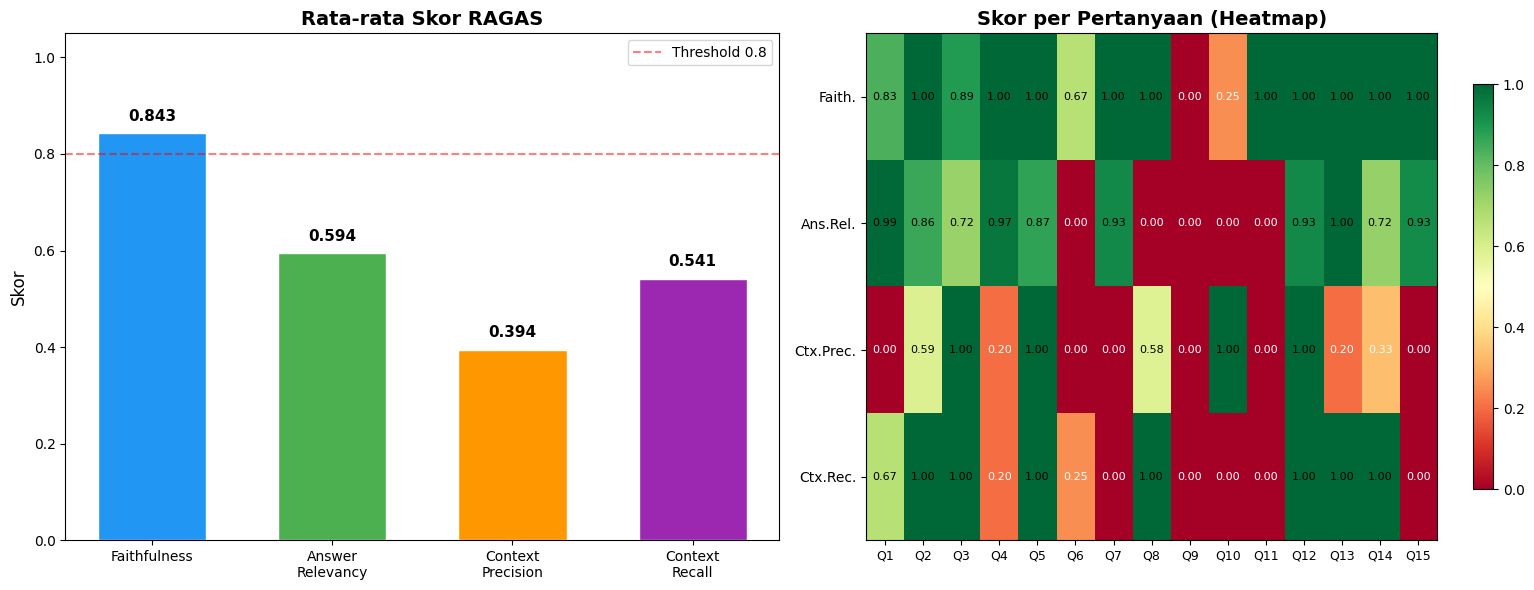

Plot disimpan ke: ragas_evaluation_results.png


In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Bar chart rata-rata skor ---
ax1 = axes[0]
metrics_names = ["Faithfulness", "Answer\nRelevancy", "Context\nPrecision", "Context\nRecall"]
metrics_values = [df[col].mean() for col in score_cols]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

bars = ax1.bar(metrics_names, metrics_values, color=colors, width=0.6, edgecolor="white")
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("Skor", fontsize=12)
ax1.set_title("Rata-rata Skor RAGAS", fontsize=14, fontweight="bold")
ax1.axhline(y=0.8, color="red", linestyle="--", alpha=0.5, label="Threshold 0.8")
ax1.legend()

# Tambahkan label nilai di atas bar
for bar, val in zip(bars, metrics_values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

# --- Plot 2: Heatmap skor per pertanyaan ---
ax2 = axes[1]
score_matrix = df[score_cols].values
q_labels = [f"Q{i+1}" for i in range(len(df))]

im = ax2.imshow(score_matrix.T, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax2.set_xticks(range(len(q_labels)))
ax2.set_xticklabels(q_labels, fontsize=9)
ax2.set_yticks(range(len(score_cols)))
ax2.set_yticklabels(["Faith.", "Ans.Rel.", "Ctx.Prec.", "Ctx.Rec."], fontsize=10)
ax2.set_title("Skor per Pertanyaan (Heatmap)", fontsize=14, fontweight="bold")

# Tambahkan nilai di setiap cell
for i in range(len(score_cols)):
    for j in range(len(q_labels)):
        val = score_matrix[j, i]
        color = "white" if val < 0.5 else "black"
        ax2.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=8)

plt.colorbar(im, ax=ax2, shrink=0.8)
plt.tight_layout()
plt.savefig("ragas_evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot disimpan ke: ragas_evaluation_results.png")

## 11. Analisis Retrieval Quality (Tanpa LLM)

Bagian ini mengevaluasi kualitas retrieval secara langsung **tanpa membutuhkan LLM**,
sehingga bisa dijalankan meskipun tidak ada API key atau Ollama.

In [18]:
# Evaluasi retrieval: apakah chunk yang di-retrieve berasal dari BAB/section yang tepat?

# Mapping pertanyaan → expected chapter/section
expected_sources = [
    {"question": "Apa saja persyaratan akademik mahasiswa untuk mengikuti Tugas Akhir?",
     "expected_chapter": "BAB I", "expected_section": "1.4"},
    {"question": "Berapa minimal SKS yang harus ditempuh untuk mengambil Tugas Akhir?",
     "expected_chapter": "BAB I", "expected_section": "1.4"},
    {"question": "Apa saja persyaratan untuk menjadi dosen pembimbing Tugas Akhir?",
     "expected_chapter": "BAB I", "expected_section": "1.4"},
    {"question": "Bagaimana tahapan pelaksanaan Tugas Akhir?",
     "expected_chapter": "BAB I", "expected_section": "1.5"},
    {"question": "Bagaimana prosedur Seminar Proposal Tugas Akhir?",
     "expected_chapter": "BAB I", "expected_section": "1.5"},
    {"question": "Apa saja bentuk Sidang Tugas Akhir?",
     "expected_chapter": "BAB I", "expected_section": "1.6"},
    {"question": "Apa saja komponen format Proposal TA?",
     "expected_chapter": "BAB II", "expected_section": "2.2"},
    {"question": "Apa perbedaan Tugas Akhir bentuk penelitian dan proyek?",
     "expected_chapter": "BAB I", "expected_section": "1.1"},
    {"question": "Apa saja sistematika penulisan laporan Tugas Akhir?",
     "expected_chapter": "BAB III", "expected_section": "3.2"},
    {"question": "Berapa lama waktu revisi Tugas Akhir setelah sidang?",
     "expected_chapter": "BAB I", "expected_section": "1.6"},
    {"question": "Apa saja komponen penilaian Sidang Tugas Akhir beserta bobotnya?",
     "expected_chapter": "BAB I", "expected_section": "1.6"},
    {"question": "Apa sanksi jika mahasiswa melakukan plagiarisme pada Tugas Akhir?",
     "expected_chapter": "BAB I", "expected_section": "1.7"},
    {"question": "Apa visi Program Studi Teknik Informatika UNISSULA?",
     "expected_chapter": "", "expected_section": ""},
    {"question": "Apa definisi Tugas Akhir menurut panduan?",
     "expected_chapter": "BAB I", "expected_section": "1.1"},
    {"question": "Apa saja kelengkapan administrasi untuk pendaftaran Seminar Proposal?",
     "expected_chapter": "LAMPIRAN", "expected_section": ""},
]

print("Evaluasi Retrieval Accuracy (tanpa LLM)")
print("=" * 70)

chapter_hits = 0
section_hits = 0
total = len(expected_sources)

for item in expected_sources:
    question = item["question"]
    expected_ch = item["expected_chapter"]
    expected_sec = item["expected_section"]

    # Retrieve
    docs = retriever.invoke(question)
    retrieved_chapters = [d.metadata.get("chapter", "") for d in docs]
    retrieved_sections = [d.metadata.get("section", "") for d in docs]

    # Chapter hit: apakah expected chapter ada di top-5?
    ch_hit = expected_ch in retrieved_chapters if expected_ch else True
    if ch_hit:
        chapter_hits += 1

    # Section hit: apakah expected section (prefix match) ada di top-5?
    sec_hit = False
    if expected_sec:
        sec_hit = any(s.startswith(expected_sec) for s in retrieved_sections if s)
    else:
        sec_hit = True  # No specific section expected
    if sec_hit:
        section_hits += 1

    status_ch = "✅" if ch_hit else "❌"
    status_sec = "✅" if sec_hit else "❌"

    print(f"\nQ: {question[:65]}...")
    print(f"  Expected : {expected_ch} / {expected_sec}")
    print(f"  Retrieved: {retrieved_chapters[:3]} / {retrieved_sections[:3]}")
    print(f"  Chapter {status_ch} | Section {status_sec}")

print("\n" + "=" * 70)
print(f"Chapter Accuracy : {chapter_hits}/{total} = {chapter_hits/total:.1%}")
print(f"Section Accuracy : {section_hits}/{total} = {section_hits/total:.1%}")

Evaluasi Retrieval Accuracy (tanpa LLM)

Q: Apa saja persyaratan akademik mahasiswa untuk mengikuti Tugas Akh...
  Expected : BAB I / 1.4
  Retrieved: ['LAMPIRAN', 'BAB I', 'BAB I'] / ['lampiran_7', '1.6.4', '1.1.1']
  Chapter ✅ | Section ❌

Q: Berapa minimal SKS yang harus ditempuh untuk mengambil Tugas Akhi...
  Expected : BAB I / 1.4
  Retrieved: ['BAB I', 'BAB IV', 'BAB IV'] / ['1.6.4', '', '']
  Chapter ✅ | Section ❌

Q: Apa saja persyaratan untuk menjadi dosen pembimbing Tugas Akhir?...
  Expected : BAB I / 1.4
  Retrieved: ['BAB I', 'BAB I', 'LAMPIRAN'] / ['1.4.2', '1.5.2', 'lampiran_1']
  Chapter ✅ | Section ✅

Q: Bagaimana tahapan pelaksanaan Tugas Akhir?...
  Expected : BAB I / 1.5
  Retrieved: ['BAB I', 'BAB I', 'BAB I'] / ['1.5.2', '1.1.1', '1.5']
  Chapter ✅ | Section ✅

Q: Bagaimana prosedur Seminar Proposal Tugas Akhir?...
  Expected : BAB I / 1.5
  Retrieved: ['BAB I', 'LAMPIRAN', 'BAB I'] / ['1.5.2', 'lampiran_8', '1.5.2']
  Chapter ✅ | Section ✅

Q: Apa saja bentuk Si

## 12. Statistik Chunk Database

In [19]:
import pandas as pd
from collections import Counter

# Ambil semua dokumen dari ChromaDB
all_data = vectorstore._collection.get(
    include=["metadatas", "documents"]
)

metadatas = all_data["metadatas"]
documents = all_data["documents"]

print(f"Total chunks di database: {len(documents)}")
print()

# --- Distribusi content_type ---
ct_counter = Counter(m.get("content_type", "unknown") for m in metadatas)
print("Distribusi Content Type:")
for ct, count in ct_counter.most_common():
    bar = "█" * (count // 2)
    print(f"  {ct:15s} {count:3d} {bar}")

print()

# --- Distribusi chapter ---
ch_counter = Counter(m.get("chapter", "(none)") for m in metadatas)
print("Distribusi Chapter:")
for ch, count in ch_counter.most_common():
    bar = "█" * (count // 2)
    print(f"  {ch or '(front matter)':20s} {count:3d} {bar}")

print()

# --- Statistik panjang chunk ---
lengths = [len(d) for d in documents]
print("Statistik Panjang Chunk (karakter):")
print(f"  Min     : {min(lengths)}")
print(f"  Max     : {max(lengths)}")
print(f"  Mean    : {sum(lengths)/len(lengths):.0f}")
print(f"  Median  : {sorted(lengths)[len(lengths)//2]}")

Total chunks di database: 247

Distribusi Content Type:
  aturan           57 ████████████████████████████
  lampiran         44 ██████████████████████
  penulisan        34 █████████████████
  persyaratan      31 ███████████████
  tabel            30 ███████████████
  prosedur         29 ██████████████
  definisi          9 ████
  visi_misi         6 ███
  flowchart         5 ██
  jadwal            2 █

Distribusi Chapter:
  LAMPIRAN              87 ███████████████████████████████████████████
  BAB I                 49 ████████████████████████
  BAB IV                47 ███████████████████████
  BAB II                19 █████████
  BAB III               17 ████████
  BAB V                 17 ████████
  (front matter)        11 █████

Statistik Panjang Chunk (karakter):
  Min     : 7
  Max     : 5843
  Mean    : 576
  Median  : 308


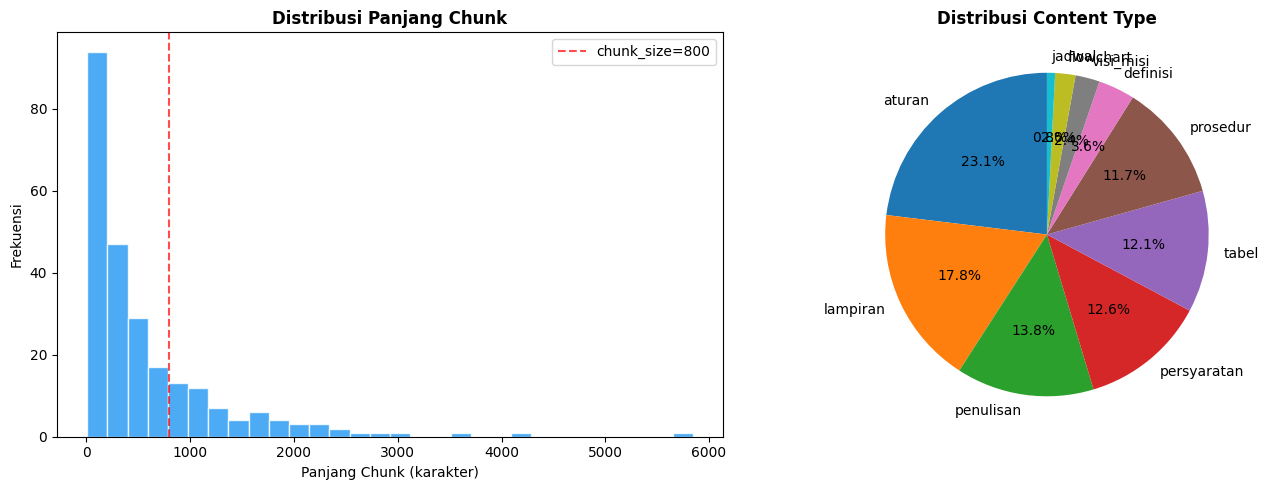

Plot disimpan ke: chunk_statistics.png


In [20]:
# Visualisasi distribusi panjang chunk
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram panjang chunk
ax1 = axes[0]
ax1.hist(lengths, bins=30, color="#2196F3", edgecolor="white", alpha=0.8)
ax1.axvline(x=800, color="red", linestyle="--", alpha=0.7, label="chunk_size=800")
ax1.set_xlabel("Panjang Chunk (karakter)")
ax1.set_ylabel("Frekuensi")
ax1.set_title("Distribusi Panjang Chunk", fontweight="bold")
ax1.legend()

# Pie chart content_type
ax2 = axes[1]
labels = [k for k, v in ct_counter.most_common()]
sizes = [v for k, v in ct_counter.most_common()]
ax2.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
ax2.set_title("Distribusi Content Type", fontweight="bold")

plt.tight_layout()
plt.savefig("chunk_statistics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot disimpan ke: chunk_statistics.png")

## 13. Inspeksi Chunk Contoh

Melihat isi beberapa chunk representatif untuk memastikan kualitas chunking.

In [21]:
# Tampilkan beberapa chunk sebagai contoh

sample_chunk_ids = [
    "bab1_1_4_1_001",   # Persyaratan Mahasiswa
    "bab1_1_5_2_004",   # Tahap Seminar Proposal
    "bab2_2_2_001",     # Format Proposal TA
    "bab1_1_6_5_001",   # Revisi Tugas Akhir
]

for target_id in sample_chunk_ids:
    # Cari chunk berdasarkan chunk_id
    found = False
    for i, meta in enumerate(metadatas):
        if meta.get("chunk_id") == target_id:
            print("=" * 70)
            print(f"CHUNK ID     : {target_id}")
            print(f"Chapter      : {meta.get('chapter')} — {meta.get('chapter_title')}")
            print(f"Section      : {meta.get('section')} — {meta.get('section_title')}")
            print(f"Content Type : {meta.get('content_type')}")
            print(f"Page         : {meta.get('page')}")
            print(f"Keywords     : {meta.get('keywords')}")
            print(f"Length       : {len(documents[i])} chars")
            print(f"-" * 70)
            # Tampilkan konten (max 500 char)
            content = documents[i]
            if len(content) > 500:
                print(content[:500] + "\n... [truncated]")
            else:
                print(content)
            print()
            found = True
            break
    if not found:
        print(f"Chunk {target_id} tidak ditemukan")

CHUNK ID     : bab1_1_4_1_001
Chapter      : BAB I — TUGAS AKHIR
Section      : 1.4.1 — Mahasiswa
Content Type : persyaratan
Page         : 13
Keywords     : 130 SKS, IPK ≥ 2, Mahasiswa

Secara, Metodologi Penelitian, Tanpa Nilai
Length       : 307 chars
----------------------------------------------------------------------
1.4.1 Mahasiswa

Secara akademik mahasiswa dapat mengikuti mata kuliah TA jika memenuhi persyaratan sebagai berikut:

• Lulus MK Metodologi Penelitian;

• Mengambil KRS TA pada semester yang sedang berjalan;

• Sekurang-kurangnya sudah lulus 130 SKS (Tanpa Nilai E) pada semester tersebut, dengan IPK ≥ 2,50

CHUNK ID     : bab1_1_5_2_004
Chapter      : BAB I — TUGAS AKHIR
Section      : 1.5.2 — 2. Tahap I : Seminar Proposal
Content Type : prosedur
Page         : 17
Keywords     : Dosen Pembimbing, Koordinator TA, Proposal TA, Seminar Kemajuan, Seminar Proposal, Seminar Proposal

Dalam Tahap, Tata Cara Tahap, Tugas Akhir, bimbingan, revisi
Length       : 1574 chars
--

## 14. Ringkasan

### Metrik Evaluasi

| Metrik | Penjelasan | Skor Ideal |
|--------|-----------|------------|
| **Faithfulness** | Jawaban sesuai konteks, tidak halusinasi | ≥ 0.80 |
| **Answer Relevancy** | Jawaban menjawab pertanyaan | ≥ 0.80 |
| **Context Precision** | Konteks yang di-retrieve tepat | ≥ 0.70 |
| **Context Recall** | Konteks mencakup semua info yang dibutuhkan | ≥ 0.70 |

### Interpretasi

- **Skor tinggi (≥ 0.80):** Pipeline chunking dan retrieval bekerja baik
- **Skor sedang (0.50–0.80):** Ada ruang perbaikan pada strategi chunking atau metadata
- **Skor rendah (< 0.50):** Perlu revisi signifikan pada pipeline

### Catatan

- Evaluasi RAGAS membutuhkan LLM sebagai judge — hasil bisa bervariasi tergantung model yang digunakan
- **Section 11** (Retrieval Accuracy) bisa dijalankan **tanpa LLM** sebagai evaluasi awal
- Untuk hasil paling akurat, gunakan OpenAI GPT-4o sebagai judge
- Ground truth bisa diperkaya dengan menambahkan lebih banyak pertanyaan dari berbagai topik

In [22]:
import pandas as pd

data = vectorstore.get()

df = pd.DataFrame({
    "Chunk ID": data["ids"],
    "Page": [m.get("page") for m in data["metadatas"]],
    "Section": [m.get("section_title") for m in data["metadatas"]],
    "Preview": [
        doc[:300] + "..."
        for doc in data["documents"]
    ]
})

df.head(10)

,Chunk ID,Page,Section,Preview
0,c9244b86-7cca-48d2-bd21-559acf39c9cc,3,,"Andi Riansyah, ST,M.Kom Badie'ah, ST,M.Kom Imam Much Ibnu Subroto, ST,M.Sc.,Ph.D Akhmad Syakhron..."
1,ea55411b-7087-43d0-962f-2434285467af,5,,"KATA PENGANTAR BIDANG AKADEMIK\n\nAssalamu ' alaikum Wr. Wb.\n\nAlhamdulillahi rabbil ' 'alamin,..."
2,308dd38f-53f4-4905-8d35-2b08070eedf3,6,,KATA PENGANTAR KETUA PROGRAM STUDI\n\nTugas akhir adalah salah satu karya penelitian mahasiswa d...
3,53a1b322-6449-4dc1-a3c3-6c2dcc1c2964,7,,DAFTAR ISI\n\nKata Pengantar Bidang Akademik\n\n................................\n\n...............
4,9ff1e54a-4af5-4cac-9da1-29f3acf105a3,9,,DAFTAR GAMBAR\n\nGambar 1.1 Flowchart Pengajuan Judul Tugas Akhir\n\n......................\n\n....
5,f62d3c09-b8c7-47c2-8851-0a6480f19c56,10,VISI dan MISI FAKULTAS TEKNOLOGI INDUSTRI UNISSULA,VISI dan MISI FAKULTAS TEKNOLOGI INDUSTRI UNISSULA...
6,3d2256f0-2105-44b4-817b-06c0b9a7506e,10,VISI,VISI\n\nMenjadi Fakultas yang berkontribusi internasional pada tahun 2024 dalam penyelenggaraan ...
7,d00872da-dc9c-4ed0-886f-11c07f0705f3,10,MISI,MISI\n\nMenyelenggarakan pendidikan tinggi bidang teknologi industri yang berorientasi pada kual...
8,332caa34-d8cd-4214-b1b2-708cf09f591b,11,Visi dan Misi Program Studi Teknik Informatika Universitas Islam Sultan Agung,Visi dan Misi Program Studi Teknik Informatika Universitas Islam Sultan Agung...
9,a9726b71-440e-4895-905b-fa935eac073b,11,Visi,Visi\n\nMenjadi program studi unggulan dalam pengembangan IPTEK di bidang Teknik Informatika yan...


In [23]:
data = vectorstore.get()

print(f"Total chunk : {len(data['documents'])}")

for i in range(10):
    print("="*80)
    print(f"Chunk {i+1}")
    print("-"*80)

    print("Metadata")
    print(data["metadatas"][i])

    print()

    print(data["documents"][i])

    print()

Total chunk : 247
Chunk 1
--------------------------------------------------------------------------------
Metadata
{'chapter': '', 'source': 'Panduan-TA-TIF-2020.pdf', 'chapter_title': '', 'document_type': 'panduan_ta', 'chunk_id': 'front_001', 'section': '', 'page': 3, 'section_title': '', 'keywords': 'Akhmad Syakhroni, Andi Riansyah, Eng Yogawati\n\nLayout, Kom Badie, Kom Imam Much Ibnu Subroto', 'content_type': 'aturan'}

Andi Riansyah, ST,M.Kom Badie'ah, ST,M.Kom Imam Much Ibnu Subroto, ST,M.Sc.,Ph.D Akhmad Syakhroni, ST,M.Eng Yogawati

Layout :

Rino Purwanto, ST.

Ketiga Februari 2020

Chunk 2
--------------------------------------------------------------------------------
Metadata
{'chapter_title': '', 'document_type': 'panduan_ta', 'keywords': 'Buku Panduan, Fakultas Teknologi Industri, KATA PENGANTAR, Log Book Tugas Akhir, Nabi Muhammad, Program Studi Teknik Informatika, Tugas Akhir', 'chunk_id': 'front_002', 'page': 5, 'section': '', 'source': 'Panduan-TA-TIF-2020.pdf', 'sec